In [19]:
# If you are using google colab, you can mount your google drive.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Fine-tuning
This notebook demonstrates fine-tuning RamanFoundation on the Bacteria-ID dataset from Ho et al. (2019).

In [20]:
# From https://github.com/csho33/bacteria-ID
!unzip '/content/drive/My Drive/data.zip'

unzip:  cannot find or open /content/drive/My Drive/data.zip, /content/drive/My Drive/data.zip.zip or /content/drive/My Drive/data.zip.ZIP.


In [21]:
# This may be colab-specific. You may need to adapt this if you are running locally
!pip install tf_keras

!export TF_USE_LEGACY_KERAS=1
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import tensorflow as tf #importing tensorflow after setting the environment variable is important

import tensorflow as tf
import tf_keras as keras
print(tf.__version__)
print(keras.__version__)

!pip install tensorflow-addons

2.20.0
2.20.0
ERROR: Could not find a version that satisfies the requirement tensorflow-addons (from versions: none)
ERROR: No matching distribution found for tensorflow-addons


In [22]:
import os
import numpy as np  # np.random.random
import matplotlib.pyplot as plt  # graphs
import datetime  # tensorboard logs naming

In [23]:
import os
import numpy as np

data_dir = '/content/drive/My Drive/Tesi_Raman/Datasets/Bacteria-ID/'

x_2018clinical = np.load(data_dir + 'X_2018clinical.npy')
y_2018clinical = np.load(data_dir + 'y_2018clinical.npy')
x_2019clinical = np.load(data_dir + 'X_2019clinical.npy')
y_2019clinical = np.load(data_dir + 'y_2019clinical.npy')

x_finetune = np.load(data_dir + 'X_finetune.npy')
y_finetune = np.load(data_dir + 'y_finetune.npy')

x_reference = np.load(data_dir + 'X_reference.npy')
y_reference = np.load(data_dir + 'y_reference.npy')

x_test = np.load(data_dir + 'X_test.npy')
y_test = np.load(data_dir + 'y_test.npy')

def shuffle_in_place(x, y):
  combined_data = np.column_stack((x, y))
  np.random.shuffle(combined_data)
  x_shuffled = combined_data[:, :-1]
  y_shuffled = combined_data[:, -1]
  return x_shuffled, y_shuffled


x_reference_shuffled, y_reference_shuffled = shuffle_in_place(x_reference, y_reference)
x_finetune_shuffled, y_finetune_shuffled = shuffle_in_place(x_finetune, y_finetune)
x_test_shuffled, y_test_shuffled = shuffle_in_place(x_test, y_test)

x_reference, y_reference = x_reference_shuffled, y_reference_shuffled
x_finetune, y_finetune = x_finetune_shuffled, y_finetune_shuffled
x_test, y_test = x_test_shuffled, y_test_shuffled


wavenumbers = np.load(data_dir + 'wavenumbers.npy')


In [24]:
class ResNet34Old:
    """Resnet34 class.
        Responsible for the Resnet 34 architecture.
    Modified from
    https://www.analyticsvidhya.com/blog/2021/08/how-to-code-your-resnet-from-scratch-in-tensorflow/#h2_2.
        View their website for more information.
    """
    def __init__(self):
        self.model = None

    def identity_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    def convolutional_block(self, x, filter):
        # copy tensor to variable called x_skip
        x_skip = x
        # Layer 1
        x = tf.keras.layers.Conv1D(filter, 3, padding="same", strides=2)(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        x = tf.keras.layers.Activation("relu")(x)
        # Layer 2
        x = tf.keras.layers.Conv1D(filter, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization(axis=2)(x)  # CHANGED: axis=3 -> axis=2 for 1D
        # Processing Residue with conv(1,1)
        x_skip = tf.keras.layers.Conv1D(filter, 1, strides=2)(x_skip)
        # Add Residue
        x = tf.keras.layers.Add()([x, x_skip])
        x = tf.keras.layers.Activation("relu")(x)
        return x

    # CHANGED: Default shape to include channel dimension
    def __call__(self, shape=(1000, 1)):
        # Step 1 (Setup Input Layer)
        x_input = tf.keras.layers.Input(shape)
        x = tf.keras.layers.ZeroPadding1D(3)(x_input)
        # Step 2 (Initial Conv layer along with maxPool)
        x = tf.keras.layers.Conv1D(64, kernel_size=7, strides=2, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPool1D(pool_size=3, strides=2, padding="same")(x)
        # Define size of sub-blocks and initial filter size
        block_layers = [3, 4, 6, 3]
        filter_size = 64
        # Step 3 Add the Resnet Blocks
        for i in range(4):
            if i == 0:
                for j in range(block_layers[i]):
                    x = self.identity_block(x, filter_size)
            else:
                filter_size = filter_size * 2
                x = self.convolutional_block(x, filter_size)
                for j in range(block_layers[i] - 1):
                    x = self.identity_block(x, filter_size)
        # Step 4 End Dense Network
        x = tf.keras.layers.AveragePooling1D(2, padding="same")(x)
        x = tf.keras.layers.Flatten()(x)
        self.model = tf.keras.models.Model(inputs=x_input, outputs=x, name="ResNet34")
        return self.model

    @property
    def layers(self):
        if self.model is None:
            raise AttributeError("Model hasn't been built yet. Call the model first.")
        return self.model.layers


def build_twin() -> keras.Model:
    """build_twin method.

    Builds a barlow twins model consisting of an encoder(resnet-34)
    and a projector, which generates embeddings for the images

    Returns:
        returns a barlow twins model
    """

    # number of dense neurons in the projector
    n_dense_neurons = 2048

    # encoder network
    resnet = ResNet34Old()()
    # resnet = create_fresh_cnn_raman()
    last_layer = resnet.layers[-1].output

    # intermediate layers of the projector network
    n_layers = 2
    for i in range(n_layers):
        dense = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{i}")
        if i == 0:
            x = dense(last_layer)
        else:
            x = dense(x)
        x = tf.keras.layers.BatchNormalization(name=f"projector_bn_{i}")(x)
        x = tf.keras.layers.ReLU(name=f"projector_relu_{i}")(x)

    x = tf.keras.layers.Dense(n_dense_neurons, name=f"projector_dense_{n_layers}")(x)

    model = keras.Model(resnet.input, x)
    return model

In [25]:
FONTSIZE_AXIS = 15
FONTSIZE_TITLE=20

In [26]:
STRAINS = {}
STRAINS[0] = "C. albicans"
STRAINS[1] = "C. glabrata"
STRAINS[2] = "K. aerogenes"
STRAINS[3] = "E. coli 1"
STRAINS[4] = "E. coli 2"
STRAINS[5] = "E. faecium"
STRAINS[6] = "E. faecalis 1"
STRAINS[7] = "E. faecalis 2"
STRAINS[8] = "E. cloacae"
STRAINS[9] = "K. pneumoniae 1"
STRAINS[10] = "K. pneumoniae 2"
STRAINS[11] = "P. mirabilis"
STRAINS[12] = "P. aeruginosa 1"
STRAINS[13] = "P. aeruginosa 2"
STRAINS[14] = "MSSA 1"
STRAINS[15] = "MSSA 3"
STRAINS[16] = "MRSA 1 (isogenic)"
STRAINS[17] = "MRSA 2"
STRAINS[18] = "MSSA 2"
STRAINS[19] = "S. enterica"
STRAINS[20] = "S. epidermidis"
STRAINS[21] = "S. lugdunensis"
STRAINS[22] = "S. marcescens"
STRAINS[23] = "S. pneumoniae 2"
STRAINS[24] = "S. pneumoniae 1"
STRAINS[25] = "S. sanguinis"
STRAINS[26] = "Group A Strep."
STRAINS[27] = "Group B Strep."
STRAINS[28] = "Group C Strep."
STRAINS[29] = "Group G Strep."

# Experiment

Here, we run the KFold Cross-Validation. The output of this code block logs the specific accuracy and losses into a text file, where summary statistics like those in Table 1 can be generated later on. We also get loss and accuracy curves similar to the ones used in Figure 7

Running finetune_pct  100 usebackbone True


------------------------------------------------------------------------
Training for fold 1 ...
Epoch 1/200
10/10 [==============================] - 32s 232ms/step - loss: 82.1371 - accuracy: 0.0288 - val_loss: 73.4173 - val_accuracy: 0.0300 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 75ms/step - loss: 67.5344 - accuracy: 0.0796 - val_loss: 59.7511 - val_accuracy: 0.0833 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 76ms/step - loss: 54.5178 - accuracy: 0.1433 - val_loss: 47.6512 - val_accuracy: 0.1150 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 75ms/step - loss: 43.0202 - accuracy: 0.2508 - val_loss: 37.0990 - val_accuracy: 0.1650 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 76ms/step - loss: 33.0151 - accuracy: 0.3587 - val_loss: 28.0227 - val_accuracy: 0.2250 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 75ms/step - loss: 24.5238 - accuracy: 0.

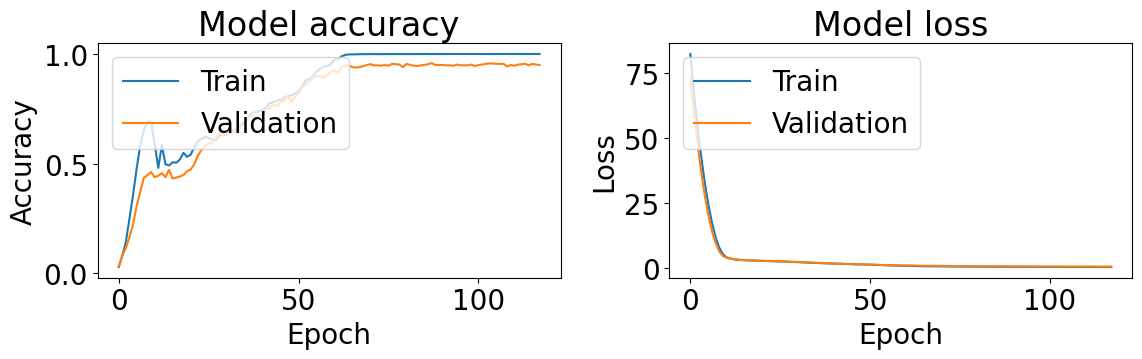

training history {'loss': [82.1370620727539, 67.53437805175781, 54.51779556274414, 43.02019119262695, 33.01509094238281, 24.523839950561523, 17.49624252319336, 12.014213562011719, 8.013401985168457, 5.444602966308594, 4.1699066162109375, 3.746575117111206, 3.4498324394226074, 3.266728401184082, 3.1390650272369385, 3.0609419345855713, 2.9900741577148438, 2.9469916820526123, 2.884592294692993, 2.8343915939331055, 2.773054599761963, 2.7533669471740723, 2.7040903568267822, 2.6522746086120605, 2.6074984073638916, 2.5853803157806396, 2.5233211517333984, 2.4814469814300537, 2.402291774749756, 2.3409857749938965, 2.297466993331909, 2.2245421409606934, 2.1578009128570557, 2.0967204570770264, 2.0333399772644043, 1.9809941053390503, 1.946333646774292, 1.8778001070022583, 1.8375871181488037, 1.797276258468628, 1.7618017196655273, 1.7054914236068726, 1.6507458686828613, 1.5988565683364868, 1.5588972568511963, 1.5057700872421265, 1.4665300846099854, 1.418541431427002, 1.399376630783081, 1.3765025138

------------------------------------------------------------------------
Training for fold 2 ...
Epoch 1/200
10/10 [==============================] - 32s 231ms/step - loss: 82.2815 - accuracy: 0.0279 - val_loss: 73.5435 - val_accuracy: 0.0350 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 75ms/step - loss: 67.6939 - accuracy: 0.0542 - val_loss: 59.9197 - val_accuracy: 0.0583 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 60ms/step - loss: 54.7210 - accuracy: 0.0746 - val_loss: 47.8388 - val_accuracy: 0.0533 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 75ms/step - loss: 43.2485 - accuracy: 0.1392 - val_loss: 37.2589 - val_accuracy: 0.1200 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 75ms/step - loss: 33.2342 - accuracy: 0.2879 - val_loss: 28.1715 - val_accuracy: 0.2183 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 74ms/step - loss: 24.7334 - accuracy: 0.

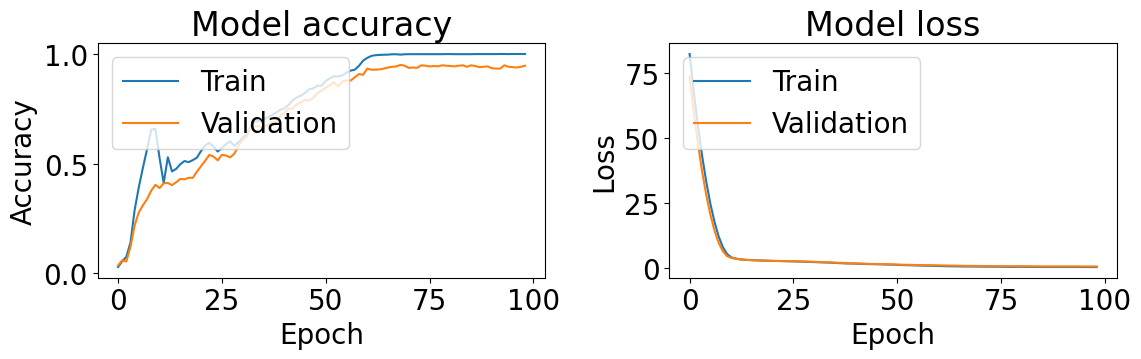

training history {'loss': [82.2814712524414, 67.69388580322266, 54.72103500366211, 43.248504638671875, 33.23423767089844, 24.73336410522461, 17.709022521972656, 12.180554389953613, 8.139139175415039, 5.522402286529541, 4.220592021942139, 3.799328565597534, 3.4972667694091797, 3.3179407119750977, 3.202254295349121, 3.1193957328796387, 3.0546514987945557, 2.999103307723999, 2.949380397796631, 2.909231662750244, 2.8458642959594727, 2.8099842071533203, 2.7822625637054443, 2.7437336444854736, 2.7000815868377686, 2.658613920211792, 2.629420757293701, 2.5701427459716797, 2.5146842002868652, 2.443420648574829, 2.3927104473114014, 2.32303786277771, 2.2765676975250244, 2.2283902168273926, 2.1666276454925537, 2.0771679878234863, 1.9904097318649292, 1.9245084524154663, 1.8638887405395508, 1.832808256149292, 1.7890000343322754, 1.7463146448135376, 1.6875923871994019, 1.6336040496826172, 1.6011855602264404, 1.550710916519165, 1.5284028053283691, 1.4778574705123901, 1.4487515687942505, 1.383547663688

------------------------------------------------------------------------
Training for fold 3 ...
Epoch 1/200
10/10 [==============================] - 31s 227ms/step - loss: 82.2703 - accuracy: 0.0500 - val_loss: 73.5397 - val_accuracy: 0.0567 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 75ms/step - loss: 67.6707 - accuracy: 0.0771 - val_loss: 59.8955 - val_accuracy: 0.0883 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 74ms/step - loss: 54.6743 - accuracy: 0.1358 - val_loss: 47.8201 - val_accuracy: 0.1333 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 75ms/step - loss: 43.1860 - accuracy: 0.2096 - val_loss: 37.2502 - val_accuracy: 0.1817 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 74ms/step - loss: 33.1954 - accuracy: 0.3258 - val_loss: 28.1720 - val_accuracy: 0.2050 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 73ms/step - loss: 24.6923 - accuracy: 0.

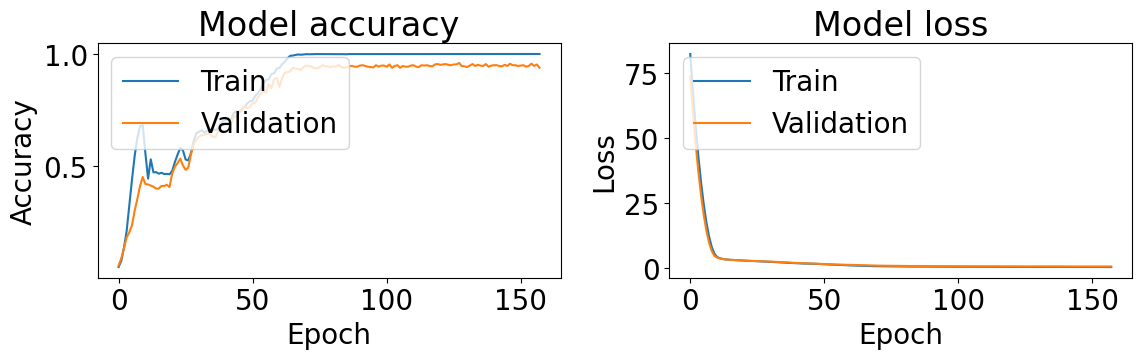

training history {'loss': [82.27025604248047, 67.67074584960938, 54.6743049621582, 43.185977935791016, 33.195438385009766, 24.692298889160156, 17.67642593383789, 12.158294677734375, 8.117317199707031, 5.5193190574646, 4.221757888793945, 3.7992103099823, 3.5014376640319824, 3.333749771118164, 3.2214694023132324, 3.1460959911346436, 3.084066867828369, 3.0234382152557373, 2.9666173458099365, 2.9085803031921387, 2.839327096939087, 2.7729389667510986, 2.725449323654175, 2.685926675796509, 2.6587891578674316, 2.613222599029541, 2.537964105606079, 2.506040334701538, 2.456685781478882, 2.407524347305298, 2.3664255142211914, 2.3170225620269775, 2.2506489753723145, 2.1805145740509033, 2.11924409866333, 2.065342903137207, 2.0105762481689453, 1.9709513187408447, 1.90972900390625, 1.856749415397644, 1.8244237899780273, 1.759759545326233, 1.7150976657867432, 1.6966073513031006, 1.6581523418426514, 1.6351819038391113, 1.6118345260620117, 1.5969123840332031, 1.5299937725067139, 1.47859525680542, 1.439

------------------------------------------------------------------------
Training for fold 4 ...
Epoch 1/200
10/10 [==============================] - 31s 226ms/step - loss: 82.4989 - accuracy: 0.0375 - val_loss: 73.7883 - val_accuracy: 0.0250 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 78ms/step - loss: 67.8857 - accuracy: 0.0546 - val_loss: 60.1026 - val_accuracy: 0.0317 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 75ms/step - loss: 54.8604 - accuracy: 0.0996 - val_loss: 47.9696 - val_accuracy: 0.0783 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 77ms/step - loss: 43.3518 - accuracy: 0.1579 - val_loss: 37.3460 - val_accuracy: 0.1150 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 77ms/step - loss: 33.3463 - accuracy: 0.2138 - val_loss: 28.2185 - val_accuracy: 0.1467 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 73ms/step - loss: 24.8561 - accuracy: 0.

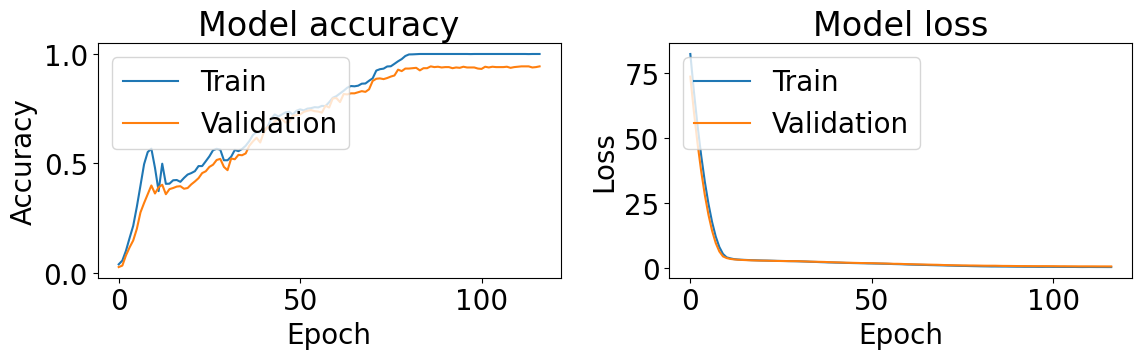

training history {'loss': [82.49890899658203, 67.8857192993164, 54.860443115234375, 43.35177230834961, 33.34626388549805, 24.8560733795166, 17.850069046020508, 12.30077838897705, 8.233016967773438, 5.576347827911377, 4.275928020477295, 3.886288642883301, 3.5935702323913574, 3.451995372772217, 3.3488805294036865, 3.287261724472046, 3.2239606380462646, 3.166926383972168, 3.131091833114624, 3.0821659564971924, 3.0454494953155518, 3.013040065765381, 2.9861979484558105, 2.947059154510498, 2.8978397846221924, 2.8752267360687256, 2.8557348251342773, 2.8123841285705566, 2.7969605922698975, 2.7698681354522705, 2.7279632091522217, 2.6851420402526855, 2.6415839195251465, 2.5708208084106445, 2.5270094871520996, 2.477590322494507, 2.416184902191162, 2.3732924461364746, 2.3207309246063232, 2.28918194770813, 2.246788740158081, 2.2120449542999268, 2.1691575050354004, 2.1251678466796875, 2.0985543727874756, 2.064789295196533, 2.0358240604400635, 2.009942054748535, 1.9844415187835693, 1.9343613386154175

------------------------------------------------------------------------
Training for fold 5 ...
Epoch 1/200
10/10 [==============================] - 33s 227ms/step - loss: 82.5700 - accuracy: 0.0404 - val_loss: 73.7994 - val_accuracy: 0.0667 - lr: 5.0000e-04
Epoch 2/200
10/10 [==============================] - 1s 77ms/step - loss: 67.9486 - accuracy: 0.0562 - val_loss: 60.1276 - val_accuracy: 0.0683 - lr: 5.0000e-04
Epoch 3/200
10/10 [==============================] - 1s 78ms/step - loss: 54.9064 - accuracy: 0.1000 - val_loss: 48.0170 - val_accuracy: 0.0783 - lr: 5.0000e-04
Epoch 4/200
10/10 [==============================] - 1s 75ms/step - loss: 43.3798 - accuracy: 0.1900 - val_loss: 37.4156 - val_accuracy: 0.1183 - lr: 5.0000e-04
Epoch 5/200
10/10 [==============================] - 1s 79ms/step - loss: 33.3407 - accuracy: 0.2754 - val_loss: 28.2649 - val_accuracy: 0.1667 - lr: 5.0000e-04
Epoch 6/200
10/10 [==============================] - 1s 77ms/step - loss: 24.7989 - accuracy: 0.

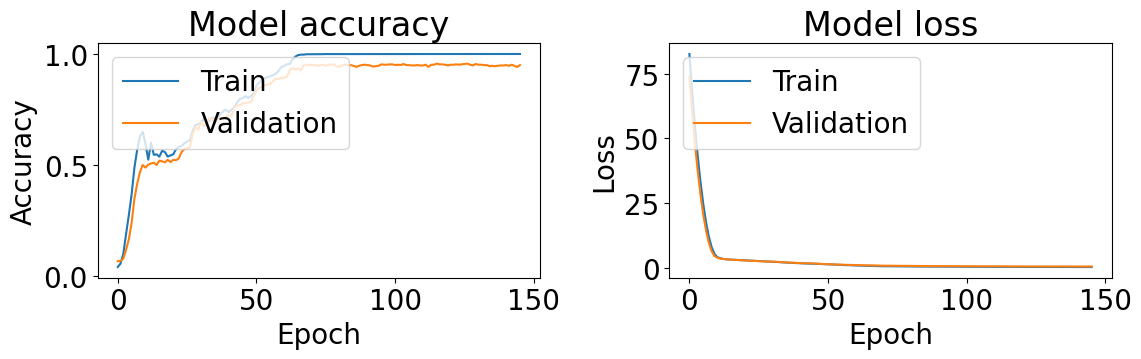

training history {'loss': [82.56998443603516, 67.94862365722656, 54.90644454956055, 43.37980651855469, 33.34074401855469, 24.79892349243164, 17.761993408203125, 12.23051929473877, 8.179617881774902, 5.5716986656188965, 4.2887372970581055, 3.8871614933013916, 3.6050772666931152, 3.453092098236084, 3.3447377681732178, 3.2753260135650635, 3.2335453033447266, 3.161498785018921, 3.1321380138397217, 3.060471296310425, 3.01949143409729, 2.9557273387908936, 2.897620916366577, 2.8669161796569824, 2.7722408771514893, 2.7007696628570557, 2.6450393199920654, 2.5837576389312744, 2.5482194423675537, 2.496980905532837, 2.4650325775146484, 2.418997049331665, 2.3715872764587402, 2.297028064727783, 2.2124183177948, 2.142186164855957, 2.0852277278900146, 2.029214382171631, 1.983198642730713, 1.9274787902832031, 1.8874820470809937, 1.8260958194732666, 1.7857118844985962, 1.7634655237197876, 1.7138383388519287, 1.6862761974334717, 1.6575089693069458, 1.6164029836654663, 1.593088984489441, 1.533625602722168

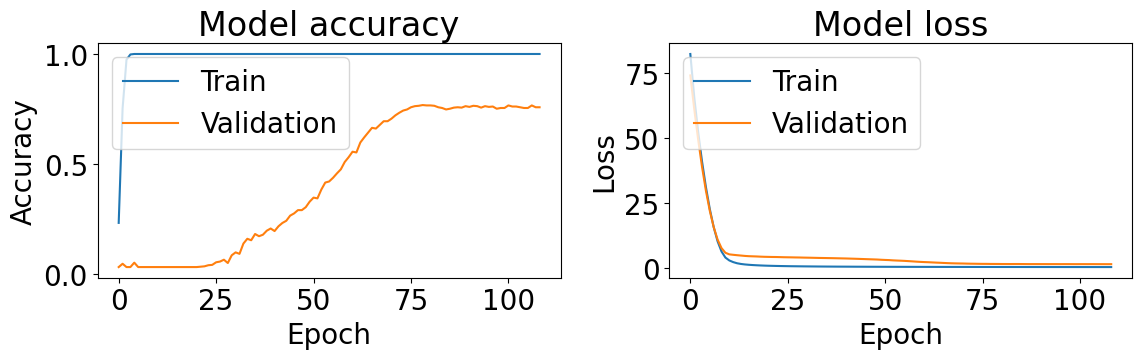

training history {'loss': [82.28897857666016, 65.81930541992188, 52.398868560791016, 40.99703598022461, 31.0919246673584, 22.61823272705078, 15.642617225646973, 10.178447723388672, 6.287100315093994, 3.9437215328216553, 2.8325397968292236, 2.1921958923339844, 1.7488311529159546, 1.4761699438095093, 1.2911771535873413, 1.159988284111023, 1.0573848485946655, 0.9739366769790649, 0.9020820260047913, 0.8425125479698181, 0.7924917936325073, 0.7540531754493713, 0.716555655002594, 0.6835507154464722, 0.6553966999053955, 0.6301977634429932, 0.6050547361373901, 0.5891544222831726, 0.5701459646224976, 0.5519694089889526, 0.5393343567848206, 0.522955596446991, 0.5097827911376953, 0.497859388589859, 0.48565176129341125, 0.4753827452659607, 0.46812108159065247, 0.4575986862182617, 0.4499818980693817, 0.44300949573516846, 0.4371247887611389, 0.43100377917289734, 0.4231041371822357, 0.4166156053543091, 0.4121454954147339, 0.40586066246032715, 0.40111029148101807, 0.3954865634441376, 0.3926597535610199

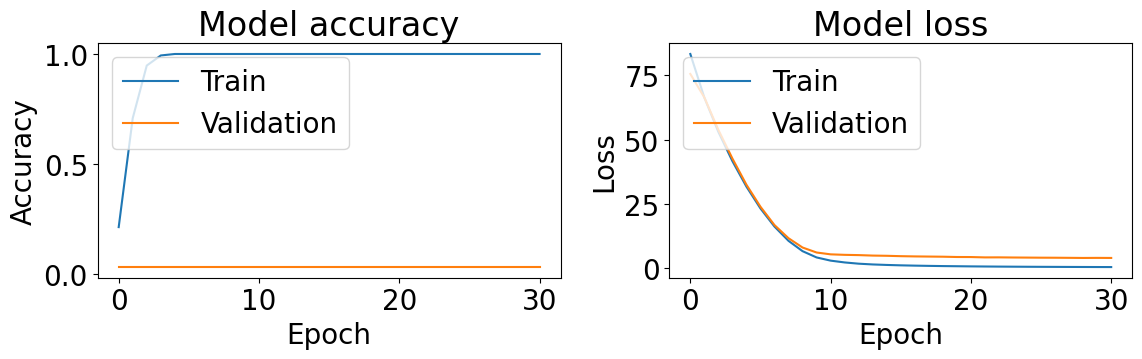

training history {'loss': [83.35231018066406, 66.40837097167969, 53.06576156616211, 41.69830322265625, 31.79591178894043, 23.307273864746094, 16.269559860229492, 10.724328994750977, 6.719706058502197, 4.283470630645752, 3.041081428527832, 2.3408048152923584, 1.8558164834976196, 1.5604795217514038, 1.3672263622283936, 1.213007926940918, 1.0985801219940186, 1.005163311958313, 0.9262768626213074, 0.8674885034561157, 0.8072196245193481, 0.7624311447143555, 0.7229366898536682, 0.6910440325737, 0.6595100164413452, 0.6341477632522583, 0.6121751666069031, 0.591805636882782, 0.57374507188797, 0.5553976893424988, 0.5418342351913452], 'accuracy': [0.21458333730697632, 0.7087500095367432, 0.9474999904632568, 0.9933333396911621, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'val_loss': [75.60149383544922, 66.44937133789062, 53.84980392456055, 42.7235221862793, 32.5418815612793, 23.98394775390625, 16.8534870147

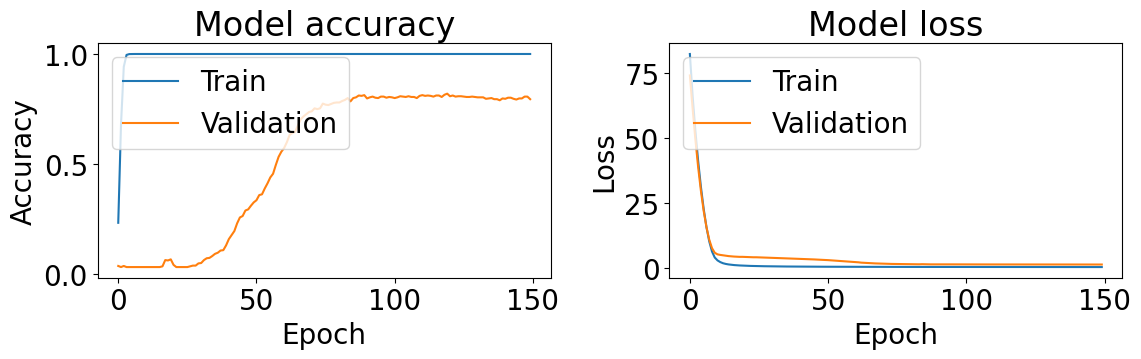

training history {'loss': [82.29003143310547, 66.0058822631836, 52.51171875, 41.0229377746582, 31.099802017211914, 22.63043975830078, 15.64669418334961, 10.172379493713379, 6.262293815612793, 3.931145429611206, 2.819997787475586, 2.174649477005005, 1.7327238321304321, 1.4614249467849731, 1.2734557390213013, 1.134940505027771, 1.0276129245758057, 0.9444675445556641, 0.8790447115898132, 0.8261545300483704, 0.7765854597091675, 0.7340242266654968, 0.7005409002304077, 0.6684414744377136, 0.6433682441711426, 0.6178149580955505, 0.5961601138114929, 0.5783811211585999, 0.5598777532577515, 0.5433159470558167, 0.5289909839630127, 0.5167039036750793, 0.504558801651001, 0.4923132359981537, 0.48062729835510254, 0.47137442231178284, 0.4622360169887543, 0.4551626145839691, 0.44733214378356934, 0.43864119052886963, 0.43244680762290955, 0.42563918232917786, 0.419798344373703, 0.41419845819473267, 0.4079911708831787, 0.4033454656600952, 0.3991642892360687, 0.39515501260757446, 0.3901329040527344, 0.3856

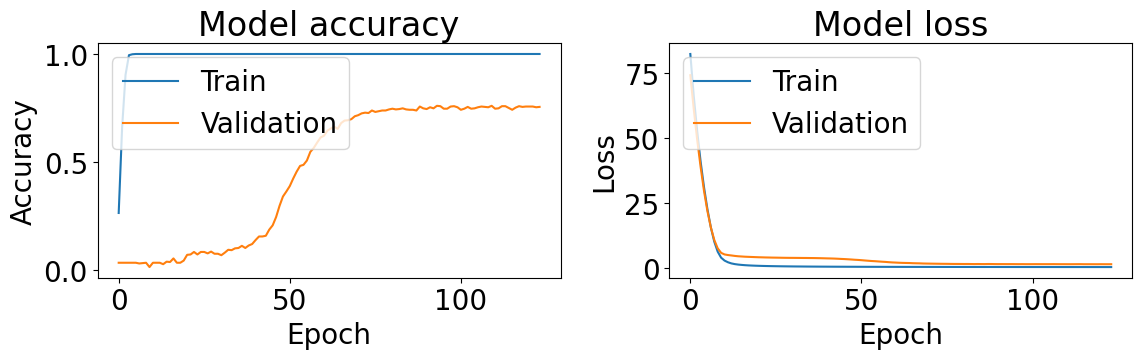

training history {'loss': [82.38142395019531, 66.21382141113281, 52.66169357299805, 41.01677322387695, 31.067909240722656, 22.575237274169922, 15.556836128234863, 10.060826301574707, 6.203635215759277, 3.886763572692871, 2.7664430141448975, 2.11759614944458, 1.6775039434432983, 1.408106803894043, 1.226880669593811, 1.097205638885498, 0.9927161931991577, 0.9119935035705566, 0.8488172888755798, 0.79416823387146, 0.7495155334472656, 0.7111349701881409, 0.6769419312477112, 0.6467350721359253, 0.6210696697235107, 0.5990262627601624, 0.5783449411392212, 0.5588580965995789, 0.542616605758667, 0.5275635719299316, 0.5117633938789368, 0.4982600510120392, 0.49067437648773193, 0.47895386815071106, 0.4674704968929291, 0.4584488570690155, 0.4491591453552246, 0.44202855229377747, 0.4331973195075989, 0.42706298828125, 0.4213389456272125, 0.4137961268424988, 0.4074667990207672, 0.4027346670627594, 0.39722540974617004, 0.39302244782447815, 0.3873026669025421, 0.3841996192932129, 0.38066530227661133, 0.3

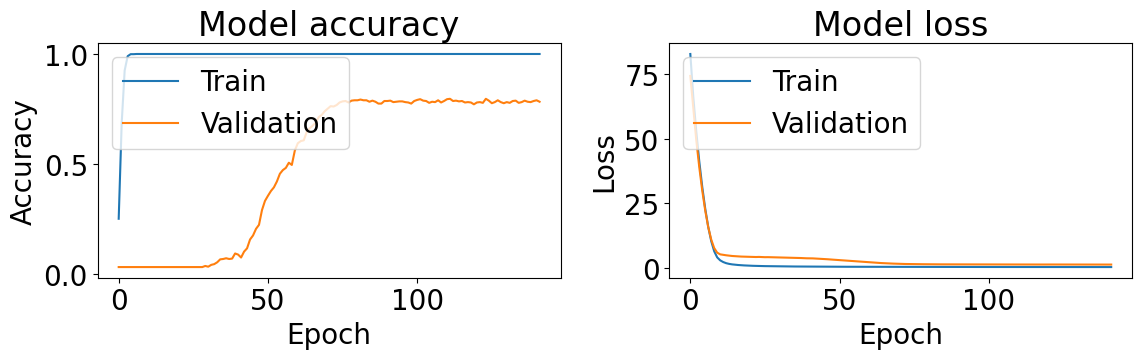

training history {'loss': [82.92617797851562, 66.19860076904297, 52.73904800415039, 41.265995025634766, 31.338586807250977, 22.870332717895508, 15.843132972717285, 10.33134937286377, 6.396999359130859, 4.021958827972412, 2.8788998126983643, 2.223562240600586, 1.7767268419265747, 1.4991976022720337, 1.3083032369613647, 1.1736117601394653, 1.0673907995224, 0.9792471528053284, 0.9085084199905396, 0.8469847440719604, 0.7970098257064819, 0.7533127069473267, 0.7166027426719666, 0.6849590539932251, 0.6591207981109619, 0.631855845451355, 0.6133484244346619, 0.5913784503936768, 0.5751845240592957, 0.5598360300064087, 0.5440674424171448, 0.5315893292427063, 0.5181593298912048, 0.5067474842071533, 0.4946499168872833, 0.48465144634246826, 0.4761831760406494, 0.4675232470035553, 0.4611316919326782, 0.45248347520828247, 0.44602081179618835, 0.4378080666065216, 0.4324093759059906, 0.4262048304080963, 0.42004162073135376, 0.4141841232776642, 0.4081757366657257, 0.4031641185283661, 0.3989490866661072, 

In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
import random
import os
import numpy as np
import tensorflow as tf

# Imposta i seed per la riproducibilità
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    # tf.config.experimental.enable_op_determinism() # Rimuovi il commento per un determinismo assoluto (può rallentare il training)

set_seeds(42)

temp_model = -1
best_model = None
best_accuracy = 0.0

def do_experiment(finetune_percent = 0.2, use_selfsupervised_backbone = True, nfolds_to_test=5):
  use_reference_warmup = False  # should we train few epochs with x_reference


  if finetune_percent < 1.0:
    xtrainpct, xtestpct, ytrainpct, ytestpct = train_test_split(x_finetune, y_finetune,
                                                                train_size=finetune_percent, random_state=42,
                                                                stratify=y_finetune,
                                                                shuffle=True)
    x_finetune_select, y_finetune_select = xtrainpct, ytrainpct
  else:
    x_finetune_select, y_finetune_select = x_finetune, y_finetune


  # fold validation and testing
  num_folds=5
  kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

  # K-fold Cross Validation model evaluation
  fold_no = 1
  for train_indices, val_indices in kfold.split(x_finetune_select, y_finetune_select):
      # Generate batches from indices
      xtrain, xval = x_finetune_select[train_indices], x_finetune_select[val_indices]
      ytrain, yval = y_finetune_select[train_indices], y_finetune_select[val_indices]
      if use_selfsupervised_backbone:
        # CARICAMENTO DEL TUO MODELLO PRE-ADDESTRATO
        bm_model_loaded = keras.models.load_model("/content/drive/My Drive/Tesi_Raman/Models/PreTrain/BarlowTwins/1000pt/FullRange/Min-Max/exp_1/ramanfoundation_pretrained_model.h5")
      else:
        bm_model_loaded = build_twin() # use random weights model

      # Do not freeze weights
      model = tf.keras.models.Sequential([
        bm_model_loaded,
        tf.keras.layers.Dense(
            30,
            activation="softmax",
            kernel_regularizer=tf.keras.regularizers.L1L2(0.05,0.05)
        )
      ])

      # Generate a print
      print('------------------------------------------------------------------------')
      print(f'Training for fold {fold_no} ...')

      if use_reference_warmup:
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, beta_1=0.5, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        history=model.fit(x_reference, y_reference, batch_size=512, epochs=5,
                                          callbacks=[
                                keras.callbacks.EarlyStopping(
                                    monitor='val_accuracy',
                                    patience=10,
                                    restore_best_weights=True
                                ),
                                keras.callbacks.ReduceLROnPlateau(
                                    monitor='val_loss',
                                    factor=0.1,
                                    patience=30,
                                    min_lr=0.0000005
                                )
                            ], validation_split=0.2
        )

        # Plot training history
        import matplotlib.pyplot as plt

        plt.figure(figsize=(12, 4))

        # Plot training & validation accuracy
        plt.subplot(1, 2, 1)
        plt.plot(history.history['accuracy'])
        plt.plot(history.history['val_accuracy'])
        plt.title('Model accuracy')
        plt.ylabel('Accuracy')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        # Plot training & validation loss
        plt.subplot(1, 2, 2)
        plt.plot(history.history['loss'])
        plt.plot(history.history['val_loss'])
        plt.title('Model loss')
        plt.ylabel('Loss')
        plt.xlabel('Epoch')
        plt.legend(['Train', 'Validation'], loc='upper left')

        plt.tight_layout()
        plt.show()

        print("train with xref and yref light")
        model.evaluate(x_test, y_test)

      model.compile(optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0005, beta_1=0.9, beta_2=0.999), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

      history = model.fit(xtrain, ytrain,
                          validation_data=(xval, yval),
                          # 256
                          batch_size=256,
                          epochs=200,
                          callbacks=[
                              keras.callbacks.EarlyStopping(
                                  monitor='val_accuracy',
                                  patience=30,
                                  restore_best_weights=True
                              ),
                              keras.callbacks.ReduceLROnPlateau(
                                  monitor='val_loss',
                                  factor=0.1,
                                  patience=30,
                                  min_lr=0.0000005
                              )
                          ]
                          #validation_split=0.2
                          )

      # Plot training history
      import matplotlib.pyplot as plt
      plt.figure(figsize=(12, 4))

      # Plot training & validation accuracy
      plt.subplot(1, 2, 1)
      plt.plot(history.history['accuracy'])
      plt.plot(history.history['val_accuracy'])
      plt.title('Model accuracy')
      plt.ylabel('Accuracy')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      # Plot training & validation loss
      plt.subplot(1, 2, 2)
      plt.plot(history.history['loss'])
      plt.plot(history.history['val_loss'])
      plt.title('Model loss')
      plt.ylabel('Loss')
      plt.xlabel('Epoch')
      plt.legend(['Train', 'Validation'], loc='upper left')

      plt.tight_layout()
      plt.show()
      history_str = str(history.history)
      print (f"training history {history_str}")


      result = model.evaluate(x_test, y_test)
      result_str = "test loss, test acc:" + str(result)
      print(f"Result: use backbone : {use_selfsupervised_backbone}, test_accuracy finetune_percent {finetune_percent}, fold_number {fold_no}, test_results {result_str}")
      result_dict = dict(zip(model.metrics_names, result))
      result_dict_str = str(result_dict)
      print(result_dict_str)

      # save result_dict_str into a txt file
      file_name = f"result_{int(finetune_percent * 100)}_backbone_{use_selfsupervised_backbone}"

      # Save the string to a file
      with open(file_name, "a") as file:
          file.write("\n"+result_dict_str)

      print(f"String saved to {file_name}")

      # You can utilize temp_model for creating certain plots like confusion matricies
      global temp_model, best_model, best_accuracy
      temp_model = model

      if result_dict['accuracy'] > best_accuracy:
          best_accuracy = result_dict['accuracy']
          best_model = model

      fold_no = fold_no + 1
      if fold_no > nfolds_to_test:
        return

# Esegue solo per il 100% dei dati
for pct in [100]:
  for usebackbone in [True, False]:
    print (f"Running finetune_pct  {pct} usebackbone {usebackbone}")
    do_experiment(pct/100.0, usebackbone,  nfolds_to_test=5)


In [31]:
import ast
import os
import numpy as np

print("=== AVERAGE ACCURACY SUMMARY ===\n")

# Analizza solo il file dei risultati per il 100% dei dati
for pct in [100]:
    for usebackbone in [True, False]:
        file_name = f"result_{pct}_backbone_{usebackbone}"
        if os.path.exists(file_name):
            with open(file_name, "r") as f:
                lines = f.readlines()
                accuracies = []
                for line in lines:
                    line = line.strip()
                    if line:
                        try:
                            # Convert the dictionary string into a real Python dictionary
                            result_dict = ast.literal_eval(line)
                            accuracies.append(result_dict['accuracy'])
                        except:
                            pass

                if accuracies:
                    avg_acc = np.mean(accuracies)
                    std_acc = np.std(accuracies)
                    print(f"-> Data used: {pct}% | Pre-trained (Backbone): {usebackbone}")
                    print(f"   Average Test Accuracy: {avg_acc*100:.2f}% (± {std_acc*100:.2f}%)\n")
        else:
            print(f"File {file_name} not found.\n")


=== AVERAGE ACCURACY SUMMARY ===

-> Data used: 100% | Pre-trained (Backbone): True
   Average Test Accuracy: 80.67% (± 0.61%)

-> Data used: 100% | Pre-trained (Backbone): False
   Average Test Accuracy: 52.81% (± 24.78%)



In [29]:
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 20}) # Adjust the value (20) as needed

Confusion matrix plot used in Figure 8

94/94 [==============================] - 2s 6ms/step


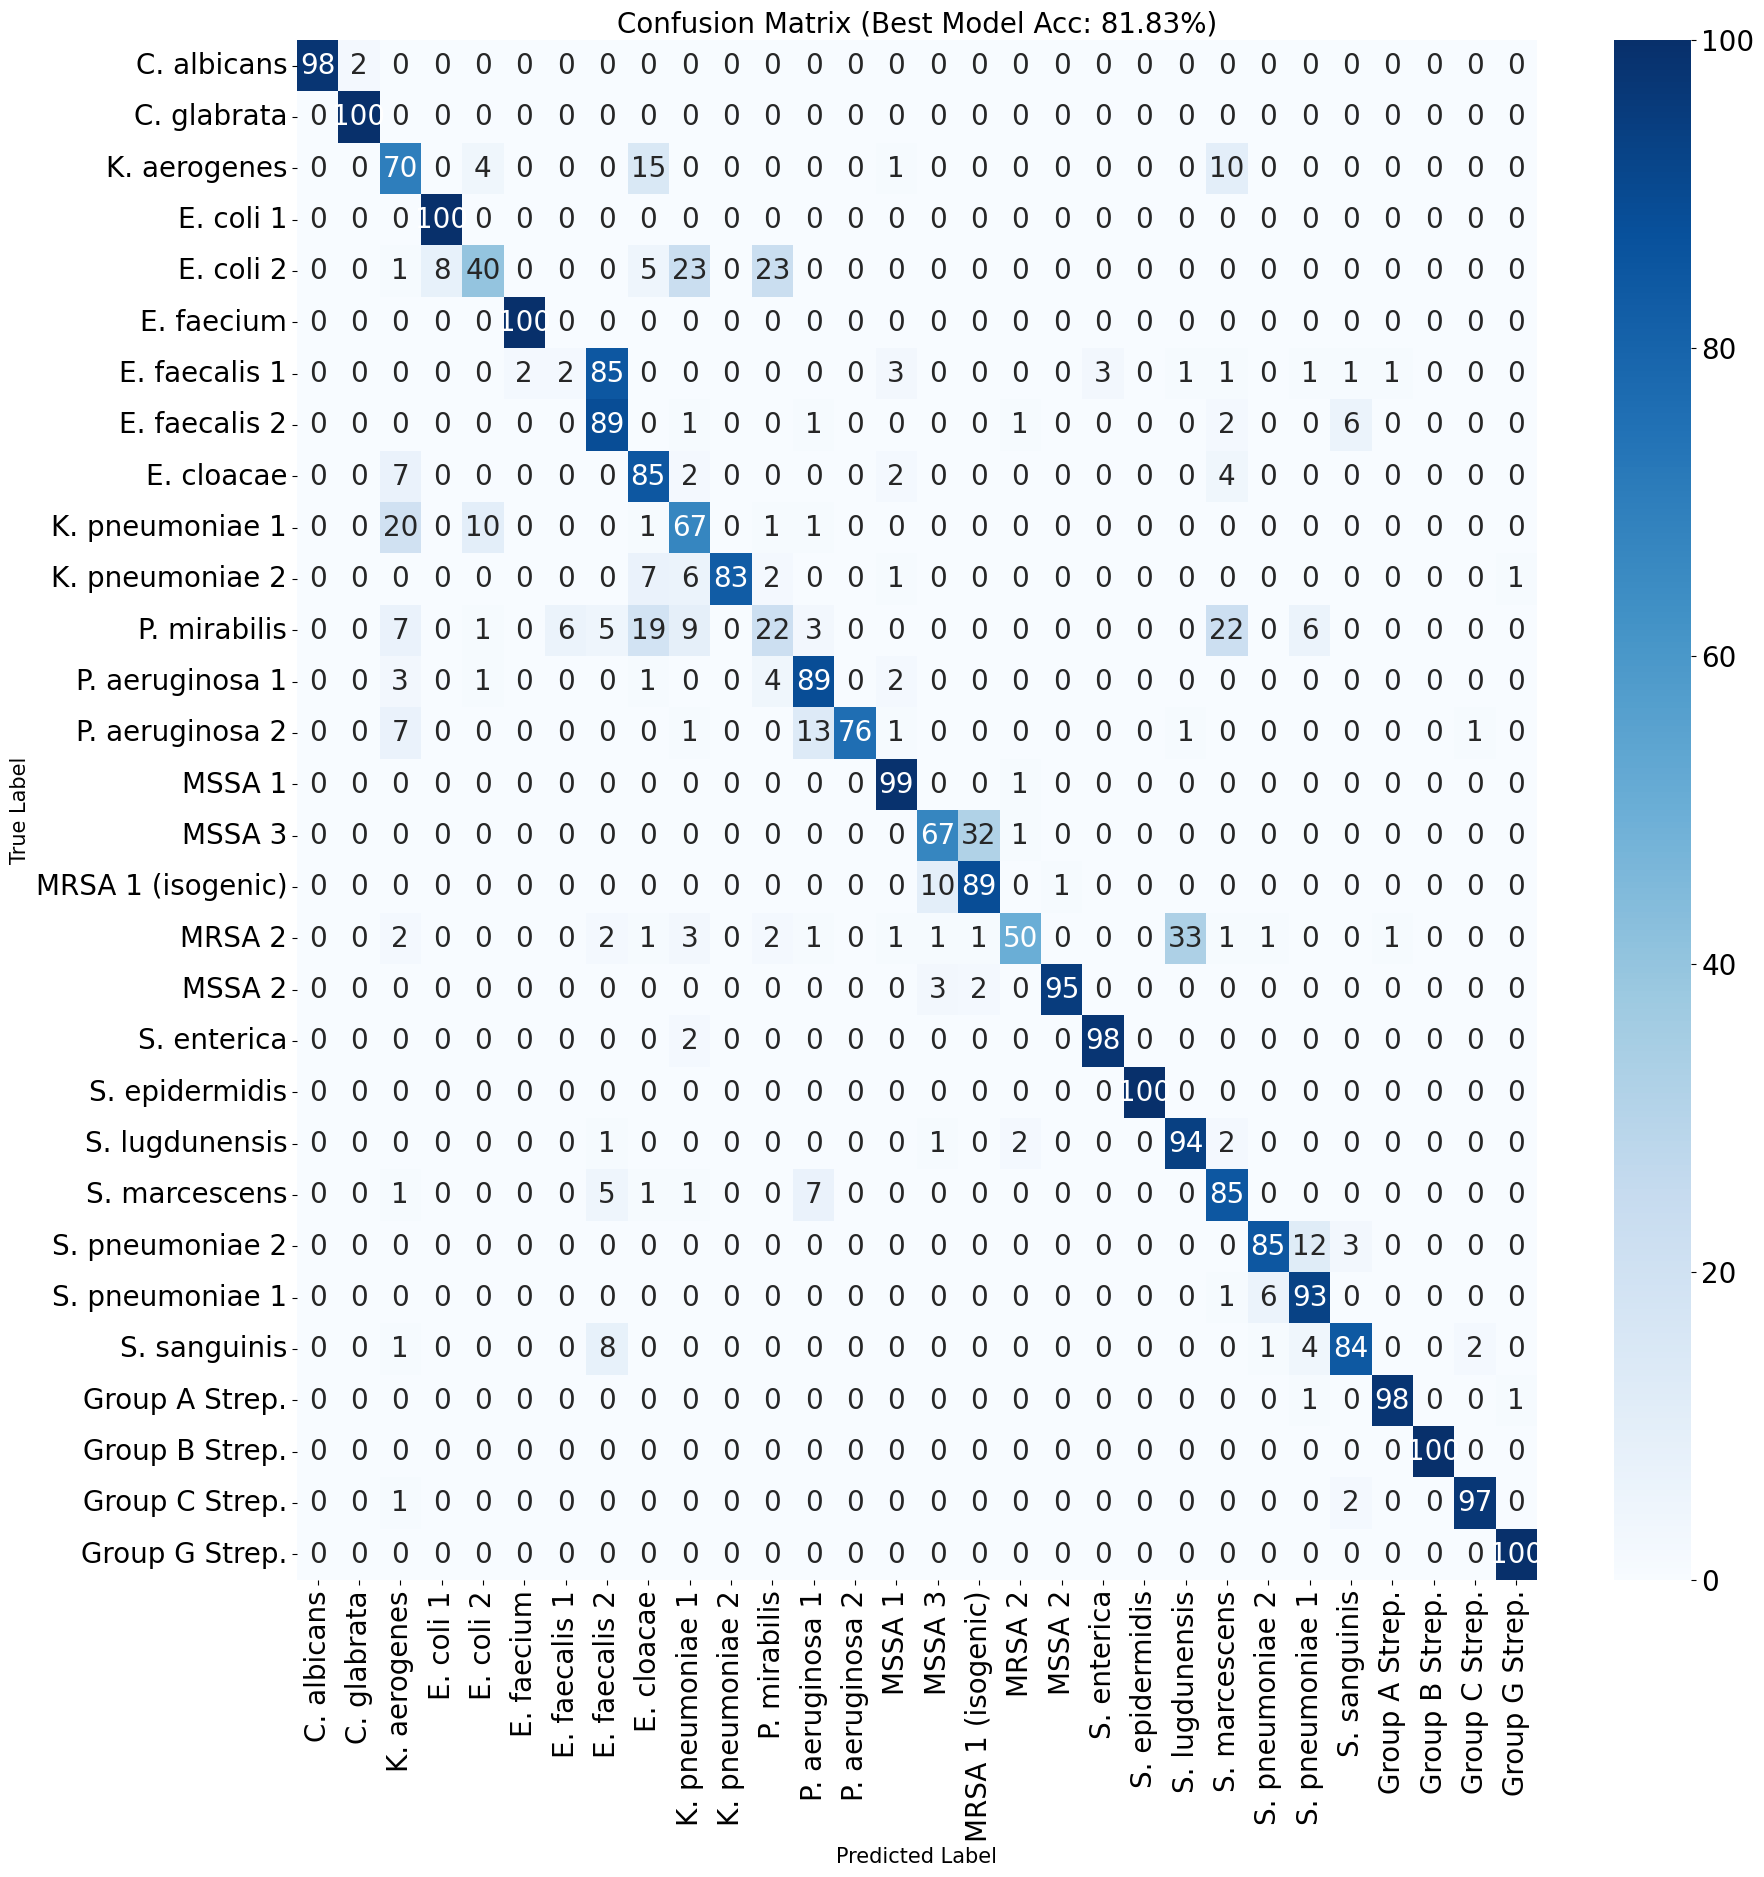

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

if 'best_model' in globals() and best_model is not None:
    y_pred = np.argmax(best_model.predict(x_test), axis=1)
    title_str = f"Confusion Matrix (Best Model Acc: {best_accuracy*100:.2f}%)"
else:
    y_pred = np.argmax(temp_model.predict(x_test), axis=1)
    title_str = "Confusion Matrix (Last Model)"

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[STRAINS[i] for i in range(30)],
            yticklabels=[STRAINS[i] for i in range(30)])
plt.xlabel("Predicted Label", fontsize=FONTSIZE_AXIS)
plt.ylabel("True Label", fontsize=FONTSIZE_AXIS)
plt.title(title_str, fontsize=FONTSIZE_TITLE)
plt.show()